### Imports

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import xgboost
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('data/clean/mp_shots_cleaner.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028007 entries, 0 to 1028006
Data columns (total 88 columns):
 #   Column                                                 Non-Null Count    Dtype  
---  ------                                                 --------------    -----  
 0   xcordadjusted                                          1028007 non-null  int64  
 1   shotangle                                              1028007 non-null  float64
 2   defendingteammaxtimeonicesincefaceoff                  1028007 non-null  float64
 3   playerpositionthatdidevent                             1028007 non-null  str    
 4   shootingteammintimeoniceofforwardssincefaceoff         1028007 non-null  float64
 5   defendingteamaveragetimeoniceofdefencemensincefaceoff  1028007 non-null  float64
 6   shotanglereboundroyalroad                              1028007 non-null  int64  
 7   time                                                   1028007 non-null  int64  
 8   shootingteamdefencemenonice      

In [4]:
int_shots = df.select_dtypes('int64').columns
float_shots = df.select_dtypes('float64').columns

df[int_shots] = df[int_shots].apply(pd.to_numeric, downcast='integer')
df[float_shots] = df[float_shots].apply(pd.to_numeric, downcast='float')

obj_shots = df.select_dtypes(include=['object']).columns

for col in obj_shots:
    num_unique = df[col].nunique()
    num_total = len(df[col])

    if num_unique / num_total < 0.5:
        df[col] = df[col].astype('category')

C:\Users\chris\AppData\Local\Temp\ipykernel_23680\1628303755.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_shots = df.select_dtypes(include=['object']).columns


In [5]:
# Find home columns (away columns use same naming conventions)
for col in df.columns:
    if 'home' in col:
        print(col)

homepenalty1length
homeemptynet
homepenalty1timeleft
hometeamgoals
ishometeam
homeskatersonice


In [6]:
# Skaters on ice, removing home/away columns
df = df.drop(columns = ['homeskatersonice', 'awayskatersonice'], errors='ignore')
df['shootingteamplayersonice'] = df['shootingteamdefencemenonice'] + df['shootingteamforwardsonice']
df['defendingteamplayersonice'] = df['defendingteamdefencemenonice'] + df['defendingteamforwardsonice']

In [7]:
# Dropping goal count and home/away empty net
df = df.drop(columns= ['hometeamgoals', 'awayteamgoals', 'awayemptynet', 'homeemptynet'], errors='ignore')

In [8]:
# Fix home/away penalty stats
df['powerplaylength'] = np.where((df['ishometeam']==1), df['homepenalty1length'], df['awaypenalty1length'])
df['penaltykilllength'] = np.where((df['ishometeam']==1), df['awaypenalty1length'], df['homepenalty1length'])
df['powerplaytimeleft'] = np.where((df['ishometeam']==1), df['homepenalty1timeleft'], df['awaypenalty1timeleft'])
df['penaltykilltimeleft'] = np.where((df['ishometeam']==1), df['awaypenalty1timeleft'], df['homepenalty1timeleft'])

In [9]:
# Drop home/away penalty stats
df = df.drop(columns = ['homepenalty1length', 'awaypenalty1length', 'homepenalty1timeleft', 'awaypenalty1timeleft'], errors='ignore')

In [10]:
# Recheck
for col in df.columns:
    if 'away' in col:
        print(col)

In [11]:
# Drop non relative and redundant measurements
df = df.drop(columns = ['xcord', 'ycord', 'shotangle', 'shotangleadjusted', 'shotdistance',
                        'lasteventxcord', 'lasteventycord', 'lasteventshotangle', 'location'],
             errors='ignore'
            )

In [12]:
# Fix lasteventteam values
df = df[df['lasteventteam'].isin(['HOME', 'AWAY'])]
df.loc[:, 'lasteventhometeam'] = df['lasteventteam'] == 'HOME'
df = df.drop(columns=['lasteventteam'], errors='ignore')
df['lasteventhometeam'] = df['lasteventhometeam'].astype('int8')

In [13]:
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [14]:
# Fix lasteventcategory values
for col in cat_cols:
    df[col] = df[col].astype('string')
    vc = df[col].value_counts()
    rare = vc[vc < 100].index
    df[col] = df[col].replace(rare, 'OTHER')

In [15]:
# Drop shotwasongoal
#   After an initial round of testing, shotwasongoal was by far the most important feature, and I realized that it is dependent on the outcome of the shot and a source of data leakage
df = df.drop(columns='shotwasongoal', errors='ignore')

### Train-test split

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [17]:
X = df.drop('goal', axis=1)
y= df['goal'].copy()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=12)

In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((719472, 73), (308346, 73), (719472,), (308346,))

In [20]:
# Scaling
scale_cols = [
    'xcordadjusted', 'time', 'lasteventshotdistance', 'averagerestdifference', 'lasteventxcord_adjusted',
    'lasteventycord_adjusted', 'timedifferencesincechange', 'timesincelastevent', 'timesincefaceoff',
    'shotangleplusrebound', 'distancefromlastevent', 'speedfromlastevent', 'ycordadjusted',
    'shotangleplusreboundspeed', 'powerplaylength', 'penaltykilllength', 'powerplaytimeleft', 'penaltykilltimeleft',
    # TOI Features
    *(c for c in X.columns if 'timeonice' in c)
]
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

In [22]:
# Get Dummies
cat_cols = X_train_scaled.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [23]:
X_train_scaled_encoded = pd.get_dummies(X_train_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = pd.get_dummies(X_test_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = X_test_scaled_encoded.reindex(columns=X_train_scaled_encoded.columns, fill_value=0)
assert list(X_train_scaled_encoded.columns) == list(X_test_scaled_encoded.columns)

In [24]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
assert list(X_train_encoded.columns) == list(X_test_encoded.columns)

In [25]:
del X_train, X_test, X_train_scaled, X_test_scaled
import gc; gc.collect()

20

# Models

In [26]:
# Imports
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [27]:
print(xgb.__version__)
print(xgb.build_info())

3.2.0
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\chris\\AppData\\Local\\Python\\pythoncore-3.13-64\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


### Parameter grids

In [107]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0,1]
}

XGB_param_grid = {
    'n_estimators':[600, 1000, 1600],
   'learning_rate':[0.02, 0.05, 0.1],
   'max_depth':[3, 6, 9],
   'subsample':[0.5, 0.9],
   'min_child_weight':[1, 5, 10]
}

RF_param_grid = {
    'n_estimators':[50, 100, 200],
    'max_depth':[3, 6, 9],
    'min_samples_leaf':[1,5,10]
}

In [108]:
# Logistic Regression
logreg_search = GridSearchCV(
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        random_state=12),
    lr_param_grid,
    n_jobs=-2,
    verbose=3,
    scoring='average_precision')

# XGBoost
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
xgboost_search = RandomizedSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=(num_neg / num_pos),
        tree_method='hist',
        device='cuda',
        random_state=12),
    XGB_param_grid,
    verbose=3,
    n_jobs=1,
    error_score='raise',
    scoring='average_precision')

# Random Forest
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        criterion='gini',
        class_weight='balanced_subsample',
        random_state=12
        ),
    RF_param_grid,
    n_jobs=-2,
    verbose=2,
    scoring='average_precision')


In [109]:
results = []

### Logistic Regression

In [110]:
logreg_search.fit(X_train_scaled_encoded, y_train)
best_idx = logreg_search.best_index_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [111]:
best_model = logreg_search.best_estimator_
logreg_test_pred = best_model.predict(X_test_scaled_encoded)
logreg_holdout_ap = average_precision_score(y_test, logreg_test_pred)

results.append({
    'model': 'LogisticRegression',
    'cv_mean': logreg_search.best_score_,
    'cv_std': logreg_search.cv_results_['std_test_score'][best_idx],
    'best_params': logreg_search.best_params_,
    'holdout_ap': logreg_holdout_ap
})


In [112]:
print(
    f'LogisticRegression '
    f'CV mean: {logreg_search.best_score_:.4f} | '
    f'CV std: {logreg_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'holdout AP: {logreg_holdout_ap:.4f}'
)
print(results)


LogisticRegression CV mean: 0.2193 | CV std: 0.0031 | holdout AP: 0.1074
[{'model': 'LogisticRegression', 'cv_mean': np.float64(0.2192843409944106), 'cv_std': np.float64(0.0031327155394738123), 'best_params': {'C': 1, 'l1_ratio': 1}, 'holdout_ap': 0.10743764247740811}]


In [113]:
logreg_importances = pd.Series(best_model.coef_.ravel(),index=X_train_scaled_encoded.columns).sort_values(key=lambda s: s.abs(), ascending=False)
logreg_importances.head(20)

shotonemptynet                               5.356349
lasteventcategory_OTHER                      2.632667
playerpositionthatdidevent_OTHER            -1.943634
defendingteamplayersonice                   -0.920035
shotrebound                                  0.720097
xcordadjusted                                0.710993
shottype_WRAP                               -0.648256
shotrush                                     0.605724
shottype_SNAP                                0.560467
shottype_SLAP                                0.559104
penaltykilllength                           -0.463503
shotanglereboundroyalroad                    0.447533
lasteventcategory_PENL                       0.446304
defendingteamaveragetimeonicesincefaceoff    0.327796
shottype_DEFL                                0.320520
shootingteamaveragetimeonicesincefaceoff     0.295667
shottype_TIP                                 0.273055
shootingteamplayersonice                     0.264697
lasteventcategory_DELPEN    

In [114]:
del logreg_search
import gc; gc.collect()

18

### XGBoost

In [115]:
xgboost_search.fit(X_train_encoded, y_train)
best_idx = xgboost_search.best_index_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\chris\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\xgboost\core.py:751: UserWarning: [11:48:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV 1/5] END learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=1000, subsample=0.9;, score=0.357 total time=   4.3s
[CV 2/5] END learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=1000, subsample=0.9;, score=0.354 total time=   3.9s
[CV 3/5] END learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=1000, subsample=0.9;, score=0.356 total time=   3.9s
[CV 4/5] END learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=1000, subsample=0.9;, score=0.364 total time=   4.1s
[CV 5/5] END learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=1000, subsample=0.9;, score=0.357 total time=   3.9s
[CV 1/5] END learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=600, subsample=0.5;, score=0.329 total time=   5.3s
[CV 2/5] END learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=600, subsample=0.5;, score=0.325 total time=   5.4s
[CV 3/5] END learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=60

In [116]:
best_model = xgboost_search.best_estimator_
xgb_test_pred = best_model.predict(X_test_encoded)
xgb_holdout_ap = average_precision_score(y_test, xgb_test_pred)

results.append({
    'model': 'XGBClassifier',
    'cv_mean': xgboost_search.best_score_,
    'cv_std': xgboost_search.cv_results_['std_test_score'][best_idx],
    'best_params': xgboost_search.best_params_,
    'holdout_ap': xgb_holdout_ap
})


In [117]:
print(
    f'XGBoostClassifier '
    f'CV mean: {xgboost_search.best_score_:.4f} | '
    f'CV std: {xgboost_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'best_params: {xgboost_search.best_params_} | '
    f'holdout AP: {xgb_holdout_ap:.4f}'
)


XGBoostClassifier CV mean: 0.3675 | CV std: 0.0044 | best_params: {'subsample': 0.9, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.05} | holdout AP: 0.1415


In [118]:
xgb_importances = pd.Series(best_model.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
xgb_importances.head(20)


shotonemptynet                          0.149497
powerplaylength                         0.053698
ishometeam                              0.052459
defendingteamplayersonice               0.052107
penaltykilllength                       0.047332
shootingteamplayersonice                0.038932
penaltykilltimeleft                     0.036031
xcordadjusted                           0.032934
shotanglereboundroyalroad               0.030534
shootingteamforwardsonice               0.030051
shotrebound                             0.028996
ycordadjusted                           0.022767
shottype_SNAP                           0.020564
shottype_WRAP                           0.019549
shootingteamdefencemenonice             0.017054
shootingteammintimeonicesincefaceoff    0.015632
shottype_TIP                            0.014485
shottype_SLAP                           0.013898
shottype_WRIST                          0.013704
lasteventcategory_HIT                   0.013200
dtype: float32

In [119]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.367538674112298),
  'cv_std': np.float64(0.004376033375600118),
  'best_params': {'subsample': 0.9,
   'n_estimators': 1000,
   'min_child_weight': 10,
   'max_depth': 6,
   'learning_rate': 0.05},
  'holdout_ap': 0.14152244326300825}]

In [120]:
del xgboost_search
import gc; gc.collect()

43

### Random Forest

In [121]:
# random forest
rf_search.fit(X_train_encoded, y_train)
best_idx = rf_search.best_index_

best_model = rf_search.best_estimator_
rf_test_pred = best_model.predict(X_test_encoded)
rf_holdout_ap = average_precision_score(y_test, rf_test_pred)

results.append({
    'model': 'RandomForestClassifier',
    'cv_mean': rf_search.best_score_,
    'cv_std': rf_search.cv_results_['std_test_score'][best_idx],
    'best_params': rf_search.best_params_,
    'holdout_ap': rf_holdout_ap
})


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [122]:
print(
    f'RandomForestClassifier '
    f'CV mean: {rf_search.best_score_:.4f} | '
    f'CV std: {rf_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'best_params: {rf_search.best_params_} | '
    f'holdout AP: {rf_holdout_ap:.4f}'
)


RandomForestClassifier CV mean: 0.2578 | CV std: 0.0017 | best_params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 9} | holdout AP: 0.1166


In [123]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.367538674112298),
  'cv_std': np.float64(0.004376033375600118),
  'best_params': {'subsample': 0.9,
   'n_estimators': 1000,
   'min_child_weight': 10,
   'max_depth': 6,
   'learning_rate': 0.05},
  'holdout_ap': 0.14152244326300825},
 {'model': 'RandomForestClassifier',
  'cv_mean': np.float64(0.2577881626899224),
  'cv_std': np.float64(0.0017227694855593643),
  'best_params': {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 9},
  'holdout_ap': 0.11663883962560126}]

In [124]:
del rf_search
import gc; gc.collect()

27

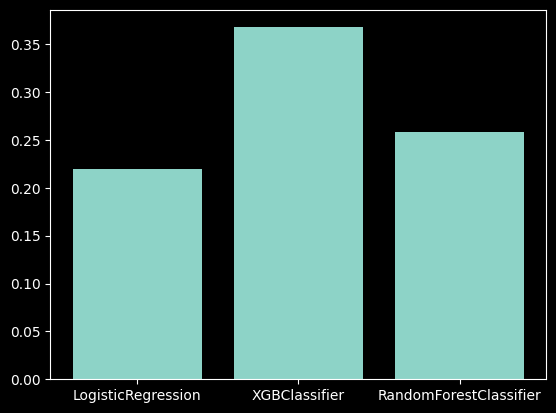

In [125]:
results_df = pd.DataFrame(results)
plt.bar(results_df['model'], results_df['cv_mean'])
plt.show()

Based on these results, the XGBClassifier performed best with an average area under the precision recall curve (PR-AUC) of 0.37. However, the number of false positives is far too high for my liking. I think I need to figure out how to tune this so that the number of predicted goals is roughly the same as the number of actual goals.

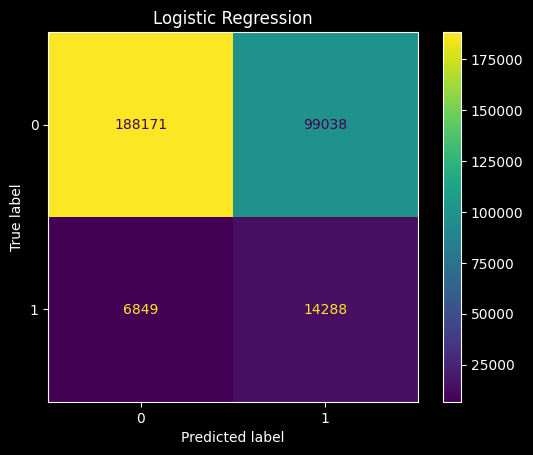

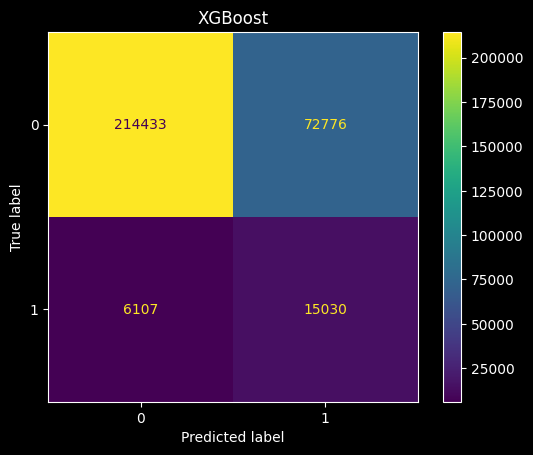

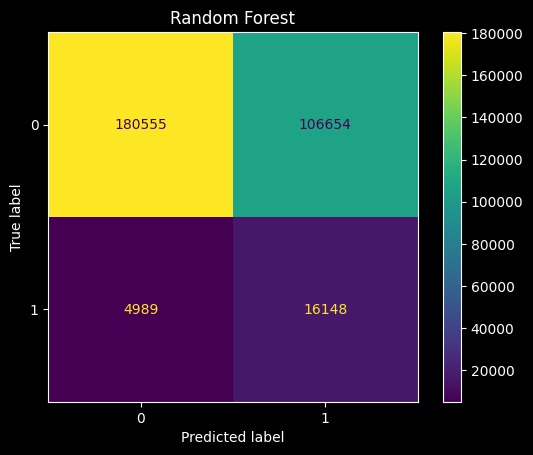

In [126]:
predictions = {
    'Logistic Regression': logreg_test_pred,
    'XGBoost': xgb_test_pred,
    'Random Forest': rf_test_pred
}
for model, prediction in predictions.items():
    cfm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(cfm)
    disp.plot()
    plt.title(model)

In [127]:
cfm = confusion_matrix(y_test, xgb_test_pred, labels=[0, 1])
print(y_test.sum()/len(y_test))
print(cfm)


0.0685496163400855
[[214433  72776]
 [  6107  15030]]


## Boosting Models

In [28]:
import lightgbm as lgb
import ipywidgets
import catboost
from catboost import CatBoostClassifier
import time
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, auc, log_loss


#### Over and Undersampling in LightGBM

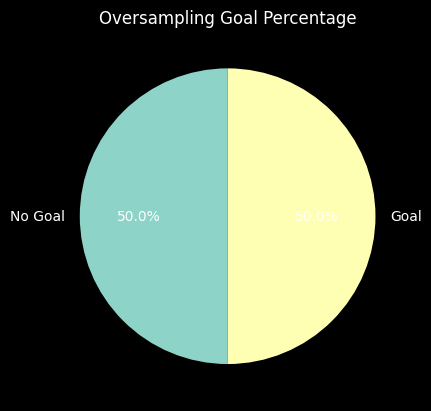

(1340302, 89)


In [29]:
# Testing oversampling
ros = RandomOverSampler(random_state=12)
X_ros, y_ros = ros.fit_resample(X_train_encoded, y_train)
pd.Series(y_ros).value_counts().plot.pie(autopct='%1.1f%%', startangle=90, title='Oversampling Goal Percentage', labels=['No Goal', 'Goal'])
plt.show()
print(X_ros.shape)

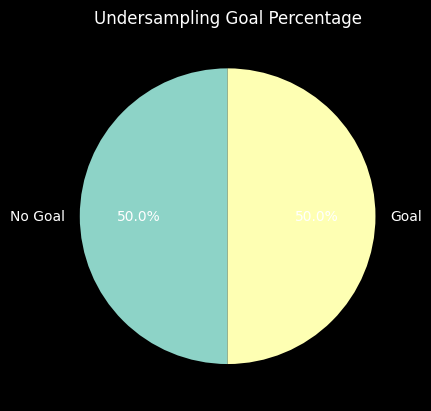

(98642, 89)


In [30]:
rus = RandomUnderSampler(random_state=12)
X_rus, y_rus = rus.fit_resample(X_train_encoded, y_train)
pd.Series(y_rus).value_counts().plot.pie(autopct='%1.1f%%', startangle=90, title='Undersampling Goal Percentage', labels=['No Goal', 'Goal'])
plt.show()
print(X_rus.shape)

In [31]:
def lgbm_search(X, y):
    """
    Grid search with varying learning rate and n_estimators for LightGBM.
    Primarily to identify whether oversampling is worthwhile.
    Outputs a dictionary with the best estimator, score, and parameters for a given X/Y pairing.
    """
    # Parameter Grid
    lgbm_param_grid = {
        'learning_rate':[0.001, 0.01, 0.1],
        'n_estimators':[100, 800, 1000]
    }

    # Model
    num_pos = (y == 1).sum()
    num_neg = (y == 0).sum()
    light_gbm = lgb.LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        scale_pos_weight=num_neg/num_pos
    )

    # Grid Search
    gs = GridSearchCV(
        light_gbm,
        param_grid=lgbm_param_grid,
        cv=5,
        n_jobs=-1,
        scoring='average_precision',
        verbose=3
    )
    # Model
    start = time.time()
    gs.fit(X, y)
    gs_train_time = time.time() - start
    # Output
    output = {
        'best_estimator':gs.best_estimator_,
        'best_score':gs.best_score_,
        'best_params':gs.best_params_,
        'train_time':gs_train_time,
    }
    return output

In [54]:
# Call lgbm_search
lgbm_os = lgbm_search(X_ros, y_ros)
lgbm_ns = lgbm_search(X_train_encoded, y_train)
lgbm_us = lgbm_search(X_rus, y_rus)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 670151, number of negative: 670151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10674
[LightGBM] [Info] Number of data points in the train set: 1340302, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 49321, number of negative: 670151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10687
[LightGBM] [Info] Number of data points

In [57]:
from joblib import dump, load
dump(lgbm_os, 'lgbm_os.joblib')
dump(lgbm_us, 'lgbm_us.joblib')
dump(lgbm_ns, 'lgbm_ns.joblib')

['lgbm_ns.joblib']

In [58]:
lgbm_os = load('lgbm_os.joblib')
lgbm_us = load('lgbm_us.joblib')
lgbm_ns = load('lgbm_ns.joblib')

In [59]:
def sample_comparison(os, ns, us):
    """
    os: oversampling results (from lgbm_search)
    ns: non oversampling results (from lgbm_search)
    us: unoversampling results (from lgbm_search)

    returns plots that compare oversampled, undersampled, and normally sampled datasets,
    including a f1/precision/recall, confusion matrix, and ROC Curves.
    """
    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))

    # ---- predictions ----
    pred_ns = ns['best_estimator'].predict(X_test_encoded)
    pred_os = os['best_estimator'].predict(X_test_encoded)
    pred_us = us['best_estimator'].predict(X_test_encoded)
    prob_ns = ns['best_estimator'].predict_proba(X_test_encoded)[:, 1]
    prob_os = os['best_estimator'].predict_proba(X_test_encoded)[:, 1]
    prob_us = us['best_estimator'].predict_proba(X_test_encoded)[:, 1]

    # ---- metrics ----
    metrics = {
        'NS': {
            'precision': precision_score(y_test, pred_ns, zero_division=0),
            'recall': recall_score(y_test, pred_ns, zero_division=0),
            'f1': f1_score(y_test, pred_ns, zero_division=0),
            'log_loss': log_loss(y_test, prob_ns),
        },
        'OS': {
            'precision': precision_score(y_test, pred_os, zero_division=0),
            'recall': recall_score(y_test, pred_os, zero_division=0),
            'f1': f1_score(y_test, pred_os, zero_division=0),
            'log_loss': log_loss(y_test, prob_os),
        },
        'US': {
            'precision': precision_score(y_test, pred_us, zero_division=0),
            'recall': recall_score(y_test, pred_us, zero_division=0),
            'f1': f1_score(y_test, pred_us, zero_division=0),
            'log_loss': log_loss(y_test, prob_us),
        }
    }

    # ---- (0,0) CV AP bar ----
    labels = ['Normally Sampled', 'Oversampled', 'Undersampled']
    scores = [ns['best_score'], os['best_score'], us['best_score']]

    bars = ax[0, 0].bar(labels, scores)
    ax[0, 0].set_title('Best CV Average Precision')
    ax[0, 0].set_ylabel('AP')
    # annotate exact values
    for bar, score in zip(bars, scores):
        ax[0, 0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{score:.4f}',
            ha='center',
            va='bottom'
        )


    # ---- (0,1) metrics text ----
    ax[0, 1].axis('off')
    ax[0, 1].text(
        0.05, 0.95,
        'Normally Sampled\n'
        f'Log Loss:  {metrics['NS']['log_loss']:.3f}\n'
        f'Precision: {metrics['NS']['precision']:.3f}\n'
        f'Recall:    {metrics['NS']['recall']:.3f}\n'
        f'F1:        {metrics['NS']['f1']:.3f}\n\n'
        'Oversampled\n'
        f'Log Loss:  {metrics['OS']['log_loss']:.3f}\n'
        f'Precision: {metrics['OS']['precision']:.3f}\n'
        f'Recall:    {metrics['OS']['recall']:.3f}\n'
        f'F1:        {metrics['OS']['f1']:.3f}\n\n'
        'Undersampled\n'
        f'Log Loss:  {metrics['US']['log_loss']:.3f}\n'
        f'Precision: {metrics['US']['precision']:.3f}\n'
        f'Recall:    {metrics['US']['recall']:.3f}\n'
        f'F1:        {metrics['US']['f1']:.3f}\n',
        transform=ax[0, 1].transAxes,
        verticalalignment='top',
        fontfamily='monospace',
    )
    # ---- (0,2) train time ----
    times = [ns['train_time'], os['train_time'], us['train_time']]
    ax[0, 2].bar(labels, times)
    ax[0, 2].set_title('Train Time')
    ax[0, 2].set_ylabel('Seconds')

    # ---- (1,0) confusion matrix NS ----
    cm_ns = confusion_matrix(y_test, pred_ns)
    ConfusionMatrixDisplay(cm_ns).plot(ax=ax[1, 0], cmap='Purples', colorbar=False, values_format='d')
    ax[1, 0].set_title('Confusion Matrix – Normally Sampled')

    # ---- (1,1) confusion matrix OS ----
    cm_os = confusion_matrix(y_test, pred_os)
    ConfusionMatrixDisplay(cm_os).plot(ax=ax[1, 1], cmap='Purples', colorbar=False, values_format='d')
    ax[1, 1].set_title('Confusion Matrix – Oversampled')

    # ---- (1,2) confusion matrix US ----
    cm_us = confusion_matrix(y_test, pred_us)
    ConfusionMatrixDisplay(cm_us).plot(ax=ax[1, 2], cmap='Purples', colorbar=False, values_format='d')
    ax[1,2].set_title('Confusion Matrix - Undersampled')

    # ---- (2,0) ROC NS ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_ns)
    roc_auc = auc(fpr, tpr)
    ax[2,0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,0].legend(loc='lower right')
    ax[2,0].set_title('ROC Curve - Normally Sampled')

    # ---- (2,1) ROC OS ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_os)
    roc_auc = auc(fpr, tpr)
    ax[2,1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,1].legend(loc='lower right')
    ax[2,1].set_title('ROC Curve - Oversampled')

    # ---- (2,2) ROC US ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_us)
    roc_auc = auc(fpr, tpr)
    ax[2,2].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,2].legend(loc='lower right')
    ax[2,2].set_title('ROC Curve - Undersampled')

    plt.tight_layout()
    return fig, ax

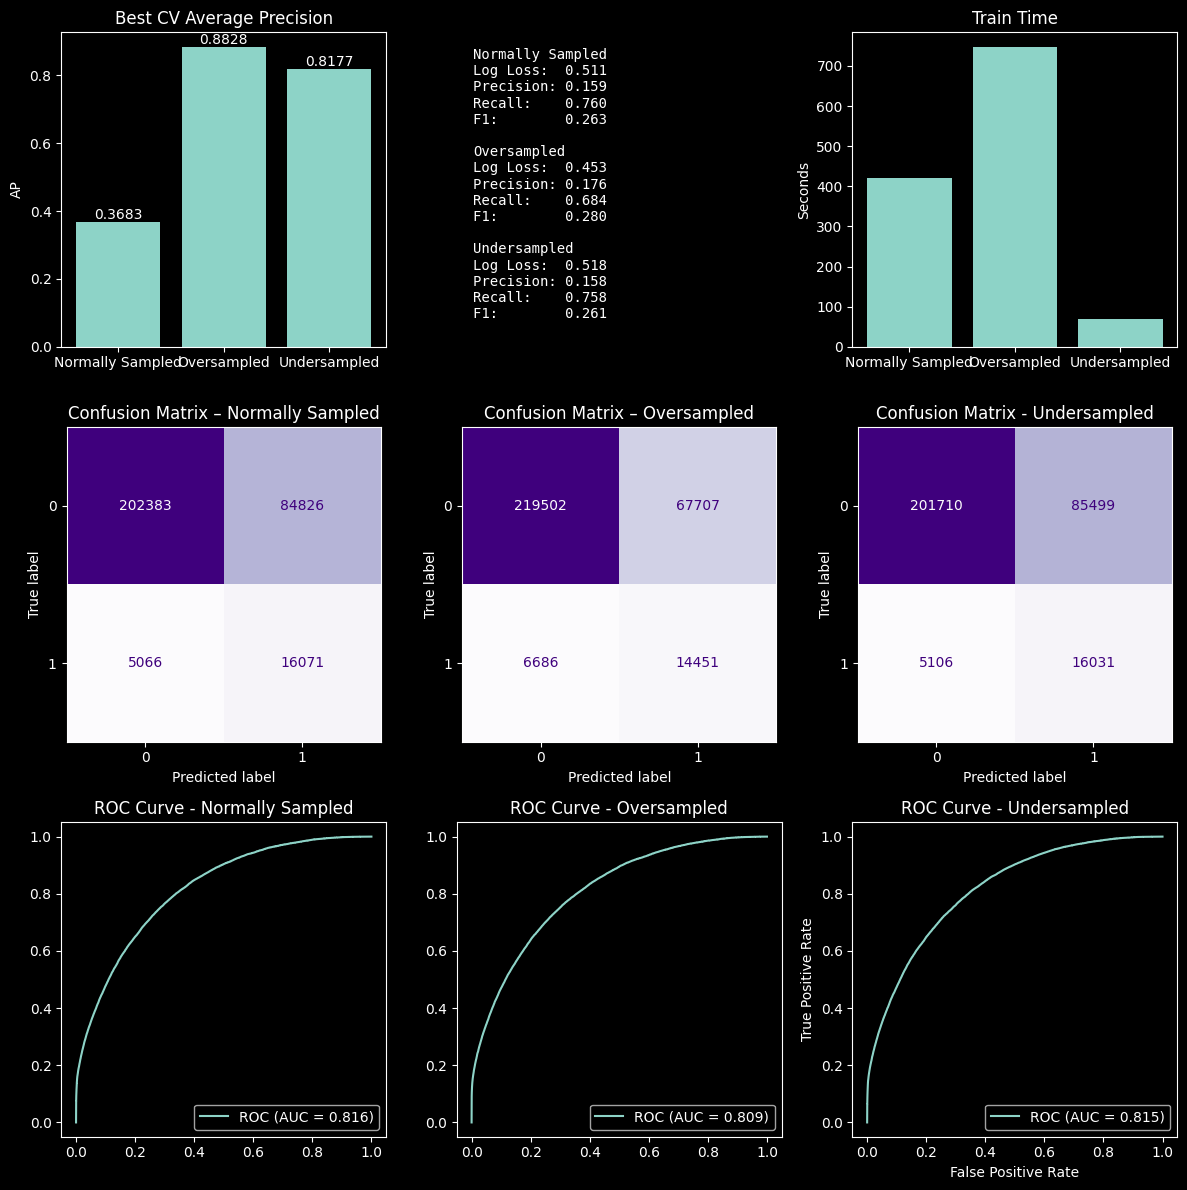

In [60]:
sample_comparison(lgbm_os, lgbm_ns, lgbm_us)

plt.show()

It seems as though oversampling offers no significant advantage over standard sampling methods, resulting in a reduction in AUC. Undersampling also decreased the AUC slightly, but to a lesser degree \
For model selection and hyperparameter tuning, I'll continue with the undersampled data to reduce processing time, as the undersampled data took significantly less time to fit.

In [61]:
# Pred/prob for regular sampling
lgbm_ns_pred = lgbm_ns['best_estimator'].predict(X_test_encoded)
lgbm_ns_prob = lgbm_ns['best_estimator'].predict_proba(X_test_encoded)[:, 1]
# Pred/prob for oversampling
lgbm_os_pred = lgbm_os['best_estimator'].predict(X_test_encoded)
lgbm_os_prob = lgbm_os['best_estimator'].predict_proba(X_test_encoded)[:, 1]

In [62]:
# Pred/prob for undersampling
lgbm_us_pred = lgbm_us['best_estimator'].predict(X_test_encoded)
lgbm_us_prob = lgbm_us['best_estimator'].predict_proba(X_test_encoded)[:, 1]

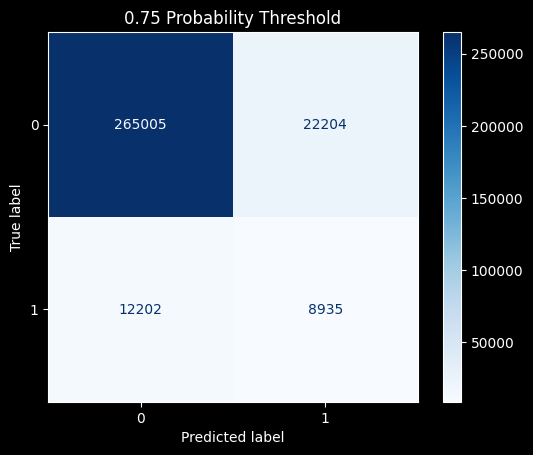

In [63]:
# Adjusting Thresholds
y_pred = (lgbm_us_prob >= 0.7).astype(int)
cfm = confusion_matrix(y_test, y_pred=y_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')
plt.title('0.75 Probability Threshold')
plt.show()

In [64]:
# Identifying the most important features
best_model = lgbm_us['best_estimator']
lgbm_importances = pd.Series(best_model.feature_importances_, index=X_rus.columns).sort_values(ascending=False)
top_30 = lgbm_importances.index[:30] # 30 features that are the most important for the model (lgbm, normal sampling)

In [65]:
imp_norm = lgbm_importances / lgbm_importances.sum()

feat_imp = (
    pd.DataFrame({
        'feature': lgbm_importances.index,
        'importance': imp_norm
    })
    .sort_values('importance', ascending=False)
)
feat_imp

,feature,importance
ycordadjusted,ycordadjusted,0.102233
xcordadjusted,xcordadjusted,0.083167
ishometeam,ishometeam,0.045133
timesincelastevent,timesincelastevent,0.043833
speedfromlastevent,speedfromlastevent,0.027167
...,...,...
lasteventcategory_FAC,lasteventcategory_FAC,0.000333
lasteventcategory_TAKE,lasteventcategory_TAKE,0.000167
playerpositionthatdidevent_OTHER,playerpositionthatdidevent_OTHER,0.000000
lasteventcategory_PENL,lasteventcategory_PENL,0.000000


In [66]:
# New X train and test using the selected features
X_train_sel = X_rus[top_30]
X_test_sel = X_test_encoded[top_30]

In [68]:
# Rerunning fit to check for change in performance
lgbm_sel = lgbm_search(X_train_sel, y_rus)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 49321, number of negative: 49321
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3351
[LightGBM] [Info] Number of data points in the train set: 98642, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [69]:
dump(lgbm_sel, 'lgbm_sel.joblib')

['lgbm_sel.joblib']

In [70]:
lgbm_sel = load('lgbm_sel.joblib')

In [71]:
sel_pred = lgbm_sel['best_estimator'].predict(X_test_sel)
sel_proba = lgbm_sel['best_estimator'].predict_proba(X_test_sel)[:, 1]

In [72]:
print(lgbm_sel['best_score'], lgbm_us['best_score']) # Comparison of average precision (PR-AUC)

0.8169455949539888 0.8176815386880513


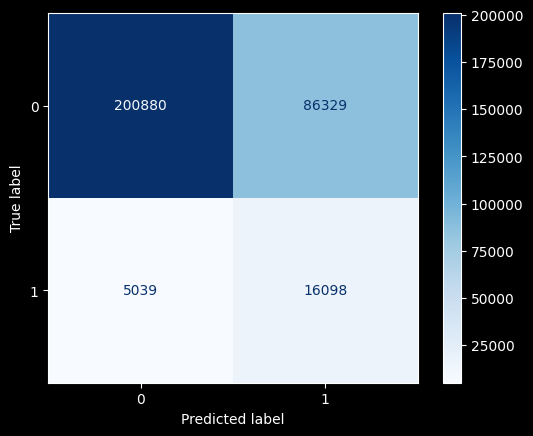

In [73]:
cfm = confusion_matrix(y_test, sel_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

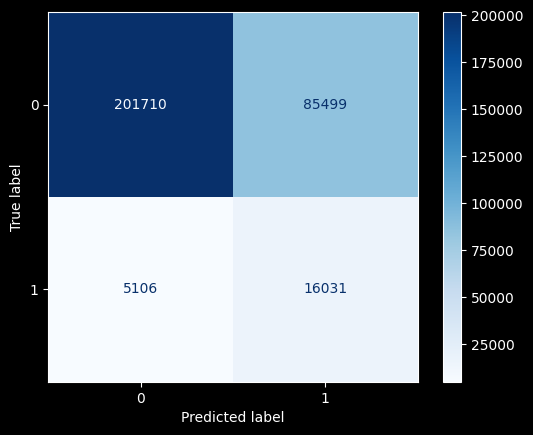

In [74]:
cfm = confusion_matrix(y_test, lgbm_us_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

In [75]:
X_train_2, X_val, y_train_2, y_val = train_test_split(X_train_sel, y_rus, test_size=0.2, stratify = y_rus, random_state=12)

In [76]:
y_val.head()

638174    1
164619    0
982818    0
777179    0
180433    1
Name: goal, dtype: int8

Light GBM

In [77]:
light_model  = lgb.LGBMClassifier(n_estimators=800, verbose=1, random_state=12)
lgbm_param_grid = {
    'learning_rate':[0.01, 0.05, 0.1],
    'min_data_in_leaf':[10, 20, 100],
    'num_leaves':[64, 128, 256]
}

In [79]:
light_search = GridSearchCV(light_model, lgbm_param_grid,  cv=5, scoring='roc_auc')
light_search.fit(X_train_2, y_train_2)
dump(light_search, 'light_search.joblib')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 31565, number of negative: 31565
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3238
[LightGBM] [Info] Number of data points in the train set: 63130, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM

['light_search.joblib']

In [80]:
light_search = load('light_search.joblib')

In [81]:
light_pred = light_search.predict(X_test_sel)
light_proba = light_search.predict_proba(X_test_sel)[:, 1]
light_search.best_score_

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10


np.float64(0.8143161763914349)

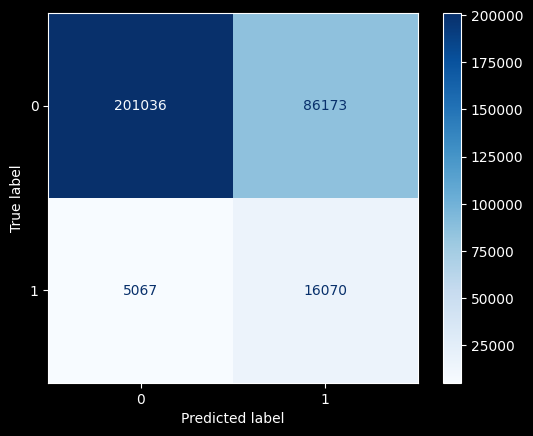

In [82]:
cfm = confusion_matrix(y_test, light_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

XG Boost

In [83]:
xgb_model  = xgb.XGBClassifier(n_estimators=1000, random_state=12, tree_method='hist', n_jobs=-1, device='cuda', verbosity=2)
xgboost_param_grid = {
    'eta':[0.01, 0.05, 0.1],
    'max_depth':[3, 5, 7, 9],
    'min_child_weight':[1, 3, 5, 10, 20]
}

In [84]:
xgb_search = GridSearchCV(xgb_model, xgboost_param_grid, cv=5, scoring='roc_auc')

In [85]:
xgb_search.fit(X_train_2, y_train_2)
dump(xgb_search, 'xgb_search.joblib')

[15:04:27] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (63130, 30, 1893900).
[15:04:27] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:170: Ellpack is dense.


C:\Users\chris\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:04:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[15:04:28] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (63130, 30, 1893900).
[15:04:28] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:170: Ellpack is dense.
[15:04:29] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (63130, 30, 1893900).
[15:04:29] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:170: Ellpack is dense.
[15:04:29] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (63131, 30, 1893930).
[15:04:29] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:170: Ellpack is dense.
[15:04:30] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (63131, 30, 1893930).
[15:04:30] INFO: C:\actions-runner\_work\xgboost\

['xgb_search.joblib']

In [86]:
xgb_search = load('xgb_search.joblib')

In [87]:
xgb_pred = xgb_search.predict(X_test_sel)
xgb_proba = xgb_search.predict_proba(X_test_sel)[:, 1]
xgb_search.best_score_

np.float64(0.8137779581100366)

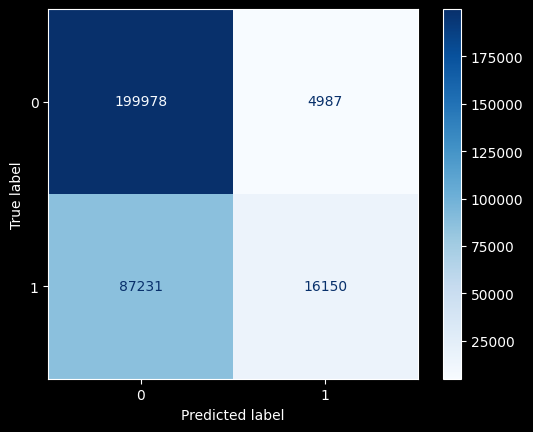

In [88]:
cfm = confusion_matrix(xgb_pred, y_test)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

Catboost

Threshold Tuning / Decile Evaluation

In [165]:
def decile_plot(probability, y_test=y_test):
    df_prob = pd.DataFrame({
        'goal_probability': probability,
        'goal_actual': y_test
    })
    df_prob = df_prob.sort_values('goal_probability', ascending=True)
    df_prob['decile'] = pd.qcut(df_prob['goal_probability'], 10, labels=False, duplicates='drop')
    deciles = (df_prob.groupby('decile').agg(
        shots = ('goal_actual', 'count'),
        goals = ('goal_actual', 'sum'),
        avg_predicted = ('goal_probability', 'mean')
    ))
    deciles['goal_rate'] = deciles['goals'] / deciles['shots']
    baseline = df_prob['goal_actual'].mean()
    deciles['lift'] = deciles['goal_rate'] - baseline


    plt.figure(figsize = (10,5))
    plt.subplot(1,2,1)
    plt.plot(deciles.index, deciles['lift'], marker='o', linestyle='dashed')
    plt.xticks(deciles.index)
    plt.xlabel('Decile')
    plt.ylabel('Lift')
    plt.title('Lift by Decile')

    plt.subplot(1,2,2)
    plt.bar(deciles.index, deciles['goals'])
    plt.xticks(deciles.index)
    plt.xlabel('Decile')
    plt.ylabel('Actual Goals')
    plt.title('Goals by Decile')

    plt.tight_layout()
    plt.show()
    return deciles

In [1]:
light_deciles = decile_plot(light_proba)

NameError: name 'decile_plot' is not defined

In [167]:
light_deciles.head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,61,0.046211,0.001978,-0.066571
1,30835,240,0.112934,0.007783,-0.060766
2,30834,420,0.163274,0.013621,-0.054928
3,30835,669,0.226696,0.021696,-0.046853
4,30834,968,0.307279,0.031394,-0.037156
5,30835,1401,0.399030,0.045435,-0.023114
6,30834,2009,0.484422,0.065155,-0.003394
7,30835,2690,0.567412,0.087239,0.018689
8,30834,3915,0.655603,0.126970,0.058421


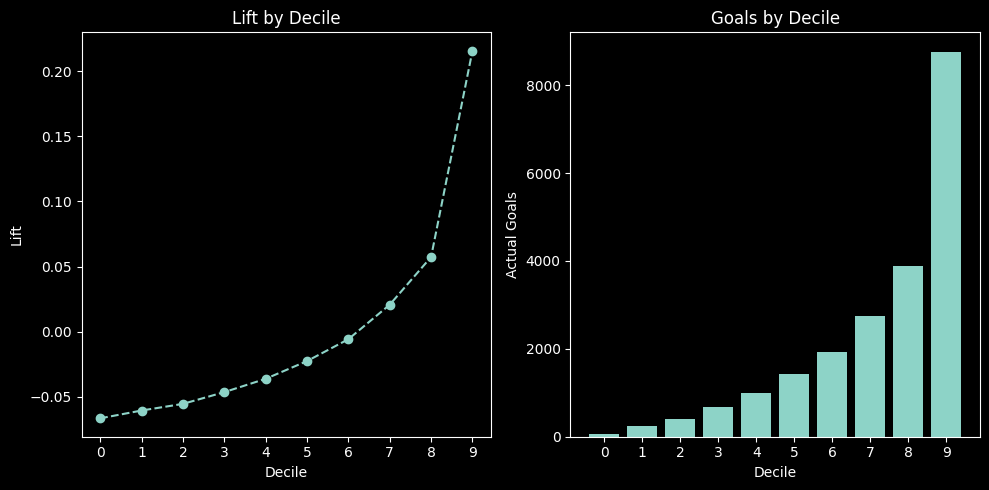

In [168]:
xgb_deciles = decile_plot(xgb_proba)

In [169]:
xgb_deciles.head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,62,0.042691,0.002011,-0.066539
1,30835,247,0.108809,0.008010,-0.060539
2,30834,404,0.161082,0.013102,-0.055447
3,30835,682,0.226720,0.022118,-0.046432
4,30834,997,0.311050,0.032334,-0.036215
5,30835,1417,0.406750,0.045954,-0.022595
6,30834,1934,0.488403,0.062723,-0.005827
7,30835,2751,0.565426,0.089217,0.020667
8,30834,3880,0.650581,0.125835,0.057286
